### Section 1 — Q1: Outcome

I analyze customer spending before and after the promotion started.  
The outcome is the amount of money each customer spent.  
I consider both spending before July 1, 2005 and after July 1, 2005.


### Section 1 — Q2: Main Effect / Predictor

The main effect is the promotion program.  
I measure it as a time indicator: before July 1, 2005 vs. after July 1, 2005.


### Section 1 — Q3: Hypothesis

H0: The mean difference in customer spending (after − before) is 0.  
HA: The mean difference in customer spending (after − before) is not 0.


### Pull data into Python

I use the provided SQL query to create a dataframe with spending before and after the promotion.


In [20]:
import sqlite3, pandas as pd

conn = sqlite3.connect("3sqlite-sakila.db")

query = """
WITH b4 AS (
  SELECT p.customer_id,
         SUM(p.amount) AS payment_before
  FROM rental r
  LEFT JOIN payment p ON p.rental_id = r.rental_id
  WHERE r.rental_date < '2005-07-01'
    AND p.amount IS NOT NULL
  GROUP BY p.customer_id
),
aft AS (
  SELECT p.customer_id,
         SUM(p.amount) AS payment_after
  FROM rental r
  LEFT JOIN payment p ON p.rental_id = r.rental_id
  WHERE r.rental_date >= '2005-07-01'
    AND p.amount IS NOT NULL
  GROUP BY p.customer_id
)
SELECT DISTINCT c.customer_id,
       c.store_id, c.first_name, c.last_name, c.active,
       b4.payment_before, aft.payment_after
FROM customer c
LEFT JOIN b4 ON b4.customer_id = c.customer_id
LEFT JOIN aft ON aft.customer_id = c.customer_id
WHERE aft.payment_after IS NOT NULL
  AND b4.payment_before IS NOT NULL;
"""

df = pd.read_sql(query, conn)
df.head()


,customer_id,store_id,first_name,last_name,active,payment_before,payment_after
0,1,1,MARY,SMITH,1,35.91,82.77
1,2,1,PATRICIA,JOHNSON,1,7.98,120.75
2,3,1,LINDA,WILLIAMS,1,30.94,104.80
3,4,2,BARBARA,JONES,1,16.94,64.84
4,5,1,ELIZABETH,BROWN,1,29.92,114.70


### Section 1 — Q4: Summary statistics and histograms

I compute summary statistics for `payment_before` and `payment_after`.  
I also create histograms to check if the values are approximately normal.


       payment_before  payment_after
count      598.000000     598.000000
mean        24.169448      88.405385
std         11.019419      22.952164
min          0.990000      27.930000
25%         15.962500      72.092500
50%         22.960000      85.825000
75%         30.930000     102.750000
max         64.870000     188.600000


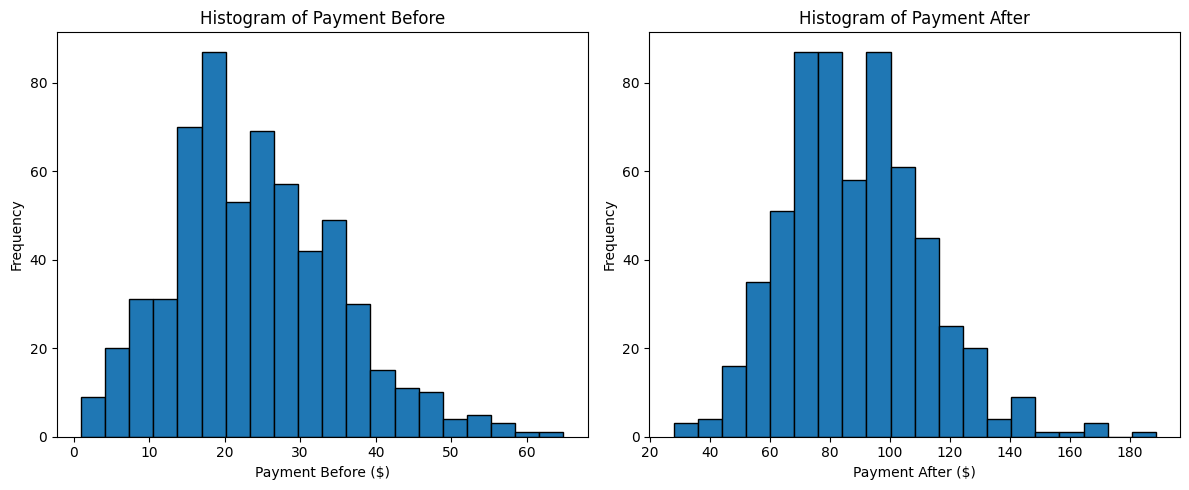

In [21]:
import matplotlib.pyplot as plt

# summary statistics
print(df[["payment_before", "payment_after"]].describe())

# histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["payment_before"], bins=20, edgecolor="black")
axes[0].set_title("Histogram of Payment Before")
axes[0].set_xlabel("Payment Before ($)")
axes[0].set_ylabel("Frequency")

axes[1].hist(df["payment_after"], bins=20, edgecolor="black")
axes[1].set_title("Histogram of Payment After")
axes[1].set_xlabel("Payment After ($)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


### Section 1 — Q5: Correlation and scatterplot

I compute the correlation between `payment_before` and `payment_after`.  
I also create a scatterplot with `payment_before` on the x-axis and `payment_after` on the y-axis.


Correlation: -0.009560452499671192


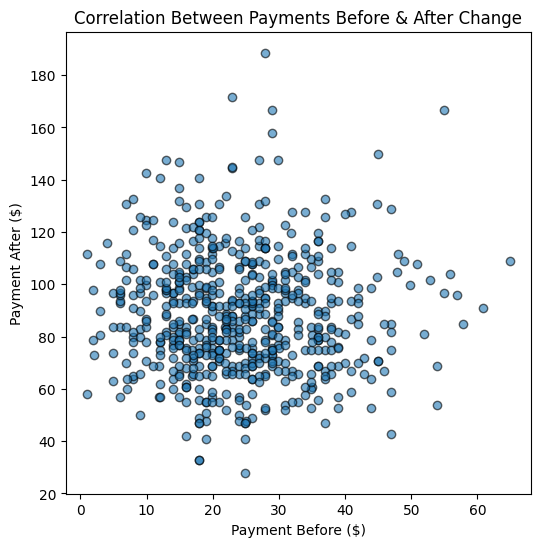

In [22]:
# correlation
corr = df["payment_before"].corr(df["payment_after"])
print("Correlation:", corr)

# scatterplot
plt.figure(figsize=(6, 6))
plt.scatter(df["payment_before"], df["payment_after"], alpha=0.6, edgecolor="black")

plt.xlabel("Payment Before ($)")
plt.ylabel("Payment After ($)")
plt.title("Correlation Between Payments Before & After Change")

plt.show()


### Section 1 — Q6: Difference variable

I compute a new variable `diff = payment_after − payment_before` to measure the change in spending for each customer.


In [23]:
df["diff"] = df["payment_after"] - df["payment_before"]
df[["customer_id", "payment_before", "payment_after", "diff"]].head()


,customer_id,payment_before,payment_after,diff
0,1,35.91,82.77,46.86
1,2,7.98,120.75,112.77
2,3,30.94,104.80,73.86
3,4,16.94,64.84,47.90
4,5,29.92,114.70,84.78


### Section 1 — Q7: Histogram of difference and one-sample t-test

I generate a histogram of the difference variable and conduct a one-sample t-test.  
The null hypothesis is that the mean of the differences equals 0.


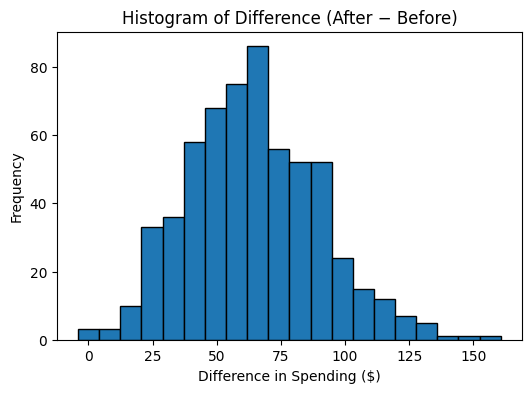

t-statistic: 61.468171170473774
p-value: 2.1475434773645048e-260
mean difference: 64.2359364548495


In [24]:
import numpy as np
from scipy import stats

# histogram of the difference
plt.figure(figsize=(6, 4))
plt.hist(df["diff"], bins=20, edgecolor="black")
plt.title("Histogram of Difference (After − Before)")
plt.xlabel("Difference in Spending ($)")
plt.ylabel("Frequency")
plt.show()

# one-sample t-test
t_stat, p_value = stats.ttest_1samp(df["diff"], 0)

print("t-statistic:", t_stat)
print("p-value:", p_value)
print("mean difference:", df["diff"].mean())


### Section 1 — Q8: Interpretation of results

I interpret the results of the one-sample t-test.  
If the p-value is less than 0.05, I reject H0 and conclude that the promotion significantly changed customer spending.  
If the p-value is greater than 0.05, I fail to reject H0 and conclude there is no significant change.  
I also report the mean of the differences to describe the direction and size of the change.
For my data, the mean difference is about 64 dollars.  
The p-value is < 0.001, so I reject H0.  
Customer spending was significantly higher after the promotion, showing the program helped increase sales.

### Section 2 — Q1: Outcome

I analyze the number of crimes in the city as the outcome variable.


### Section 2 — Q2: Main Effect / Predictor

The main effect is daily temperature in degrees Fahrenheit.


### Section 2 — Q3: Hypothesis

H0: Temperature has no effect on the number of crimes.  
HA: Higher temperature is associated with a higher number of crimes.


### Section 2 — Q4: Descriptive statistics and plots

I compute summary statistics for crimes and temperature.  
I also create histograms to examine the distributions.


       Temperature_F      Crimes
count     178.000000  178.000000
mean       79.404494   29.382022
std        10.384929    4.029568
min        57.000000   20.000000
25%        72.000000   26.250000
50%        79.000000   30.000000
75%        87.000000   32.000000
max       105.000000   40.000000


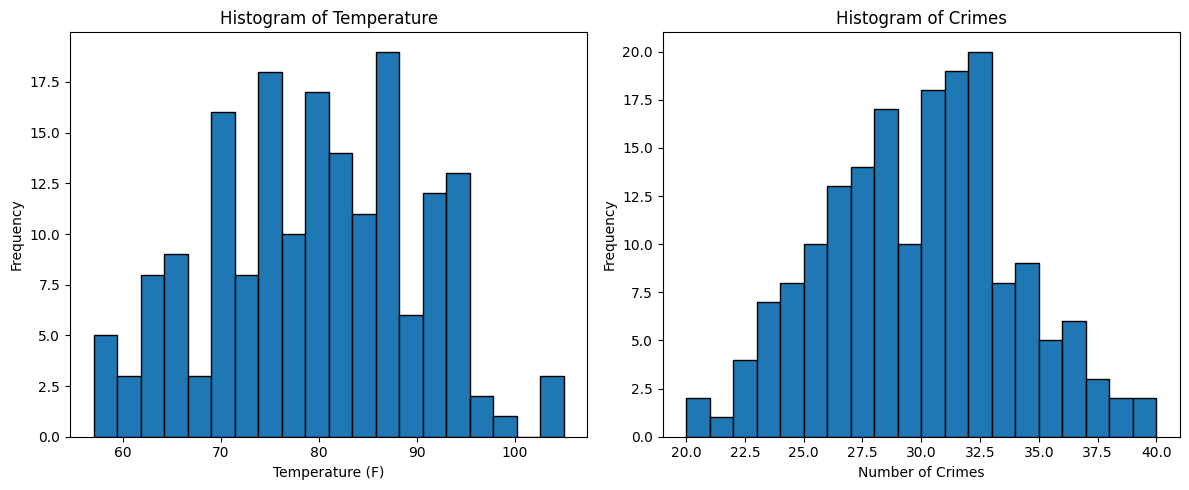

In [25]:
# summary statistics
print(crimes[["Temperature_F", "Crimes"]].describe())

# histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(crimes["Temperature_F"], bins=20, edgecolor="black")
axes[0].set_title("Histogram of Temperature")
axes[0].set_xlabel("Temperature (F)")
axes[0].set_ylabel("Frequency")

axes[1].hist(crimes["Crimes"], bins=20, edgecolor="black")
axes[1].set_title("Histogram of Crimes")
axes[1].set_xlabel("Number of Crimes")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


### Section 2 — Q5: Correlation and scatterplot

I compute the correlation between temperature and crimes.  
I also create a scatterplot with temperature on the x-axis and crimes on the y-axis.


Correlation: 0.8230854321489975


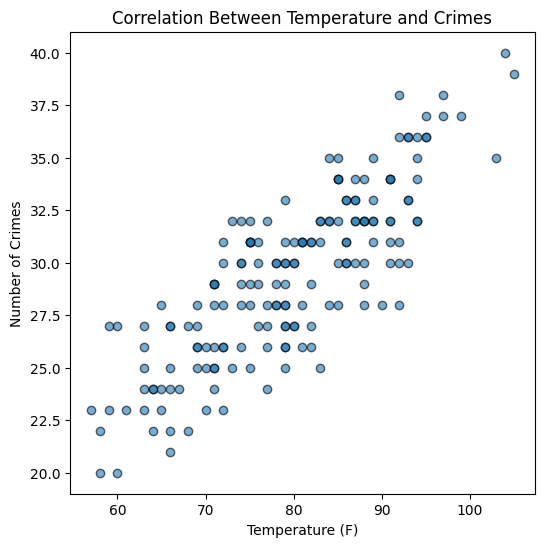

In [26]:
# correlation
corr = crimes["Temperature_F"].corr(crimes["Crimes"])
print("Correlation:", corr)

# scatterplot
plt.figure(figsize=(6, 6))
plt.scatter(crimes["Temperature_F"], crimes["Crimes"], alpha=0.6, edgecolor="black")

plt.xlabel("Temperature (F)")
plt.ylabel("Number of Crimes")
plt.title("Correlation Between Temperature and Crimes")

plt.show()


### Section 2 — Q6: Regression analysis

I use a linear regression model to test whether temperature predicts the number of crimes.  
I use the statsmodels library and print the summary of results.


In [27]:
import statsmodels.api as sm

# define variables
X = crimes["Temperature_F"]
y = crimes["Crimes"]

# add constant term for intercept
X = sm.add_constant(X)

# fit regression model
model = sm.OLS(y, X).fit()

# show summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                 Crimes   R-squared:                       0.677
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     369.7
Date:                Mon, 29 Sep 2025   Prob (F-statistic):           4.13e-45
Time:                        16:04:13   Log-Likelihood:                -399.43
No. Observations:                 178   AIC:                             802.9
Df Residuals:                     176   BIC:                             809.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             4.0223      1.330      3.024

### Section 2 — Q7: Results interpretation

I interpret the regression output as follows:

- **Coefficient for Temperature_F:** This shows how many crimes are expected to change for each 1°F increase in temperature.  
- **Intercept:** This is the expected number of crimes when temperature is zero (not meaningful in practice, but part of the model).  
- **R-squared:** This indicates how much of the variation in crimes is explained by temperature.  
- **p-value for Temperature_F:** If it is less than 0.05, I conclude that temperature is a statistically significant predictor of crimes.  

Based on these results, I decide whether the hypothesis that higher temperature is associated with more crimes is supported.


The regression coefficient for Temperature_F is 0.319 (p < 0.001).  
This means each 1°F increase is associated with about 0.32 more crimes per day.  
R-squared is about 0.68, so temperature explains 68% of the variation in crimes.  
This strongly supports the hypothesis that crime is higher on hotter days.


### Section 2 — Q8: Residual plot

I create a plot of standardized residuals against temperature to check the assumptions of linear regression.  
If the residuals are roughly centered around zero with no clear pattern, the assumptions are reasonable.


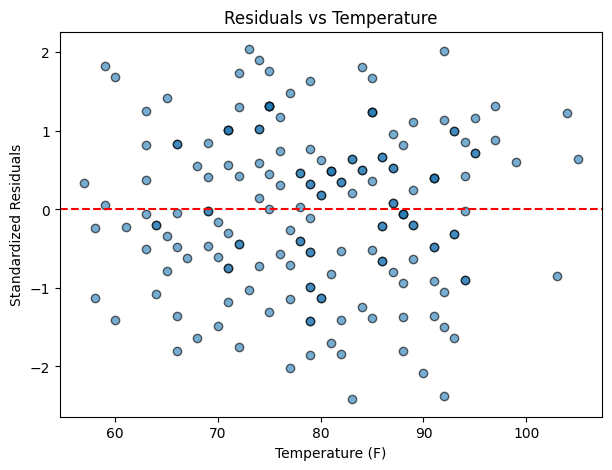

In [28]:
# get standardized residuals
influence = model.get_influence()
resid = influence.resid_studentized_internal

# plot residuals vs temperature
plt.figure(figsize=(7,5))
plt.scatter(crimes["Temperature_F"], resid, alpha=0.6, edgecolor="black")
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Temperature (F)")
plt.ylabel("Standardized Residuals")
plt.title("Residuals vs Temperature")

plt.show()


The residual plot shows points scattered randomly around zero with no clear pattern.  
This suggests that the linear regression assumptions are reasonably met.


### Section 3: Linear Algebra Regression

I fit the same regression model using the linear algebra formula:

β = (X'X)^(-1) X'y  

Then I compare these coefficients to the ones obtained from statsmodels.


In [29]:
import numpy as np

# construct X matrix with constant and temperature
X = np.column_stack((np.ones(len(crimes)), crimes["Temperature_F"].values))
y = crimes["Crimes"].values.reshape(-1, 1)

# compute betas using OLS closed-form
beta = np.linalg.inv(X.T @ X) @ (X.T @ y)

print("Coefficients (Linear Algebra):")
print("Intercept:", beta[0,0])
print("Temperature_F:", beta[1,0])

# compare to statsmodels
print("\nCoefficients (statsmodels):")
print(model.params)


Coefficients (Linear Algebra):
Intercept: 4.022276636195784
Temperature_F: 0.3193741869787097

Coefficients (statsmodels):
const            4.022277
Temperature_F    0.319374
dtype: float64


### Section 3 — Interpretation

The coefficients from the linear algebra method and the statsmodels OLS are the same.  
This happens because both approaches solve the same Ordinary Least Squares (OLS) problem.  
- The formula β = (X'X)^(-1) X'y is the closed-form solution for OLS.  
- The statsmodels OLS function also estimates coefficients using OLS.  

Any small differences are due to numerical precision, but the results are mathematically equivalent.
